In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # suppress TF logs

In [2]:
import pandas as pd
import numpy as np
import pickle
import time

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import SGDClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.enssemble import RandomForestClassifier
from sklearn.metrics import classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv1D, Flatten, LSTM

start = time.time()

# -------------------------------
# LOAD DATA
# -------------------------------
df1 = pd.read_csv(r"C:\Users\Administrator\OneDrive\Desktop\RIDS\SEM 6\AWID-CLS-TST.csv")
df2 = pd.read_csv(r"C:\Users\Administrator\OneDrive\Desktop\RIDS\SEM 6\CIC-IDS2017-Wednesday.csv")
df3 = pd.read_csv(r"C:\Users\Administrator\OneDrive\Desktop\RIDS\SEM 6\KDDTrain+.csv")

print("✅ Data Loaded")

# -------------------------------
# SAFE LABEL DETECTION
# -------------------------------
def find_label(df):
    possible = ['label', 'Label', 'class', 'Class', 'attack', 'Attack']
    for col in df.columns:
        if col in possible:
            return col
    return df.columns[-1]

label1 = find_label(df1)
label2 = find_label(df2)
label3 = find_label(df3)

print("Labels:", label1, label2, label3)

# -------------------------------
# SPLIT FEATURES & LABEL
# -------------------------------
X1, y1 = df1.drop(columns=[label1]), df1[label1]
X2, y2 = df2.drop(columns=[label2]), df2[label2]
X3, y3 = df3.drop(columns=[label3]), df3[label3]

# -------------------------------
# ALIGN FEATURES
# -------------------------------
all_cols = list(set(X1.columns) | set(X2.columns) | set(X3.columns))

def align(df, cols):
    for c in cols:
        if c not in df.columns:
            df[c] = 0
    return df[cols]

X1 = align(X1, all_cols)
X2 = align(X2, all_cols)
X3 = align(X3, all_cols)

# -------------------------------
# COMBINE
# -------------------------------
X = pd.concat([X1, X2, X3], axis=0)
y = pd.concat([y1, y2, y3], axis=0)

y = y.astype(str)

print("Shape:", X.shape)

# -------------------------------
# FAST PREPROCESSING
# -------------------------------
for col in X.columns:
    if X[col].dtype == "object":
        X[col] = pd.factorize(X[col])[0]

X = X.apply(pd.to_numeric, errors='coerce').fillna(0)

# Convert to numpy
X = X.values.astype(np.float32)

# Encode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# -------------------------------
# SPLIT
# -------------------------------
X_temp, X_test, y_temp, y_test = train_test_split(X, y_encoded, test_size=0.15, random_state=42)

X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.176, random_state=42)

print("✅ Split done")

# -------------------------------
# SCALING
# -------------------------------
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train).astype(np.float32)
X_val = scaler.transform(X_val).astype(np.float32)
X_test = scaler.transform(X_test).astype(np.float32)

# -------------------------------
# TRAIN MODELS
# -------------------------------
models = {}

print("🚀 Training ML models...")

svm = SGDClassifier(loss='hinge', max_iter=200)
svm.fit(X_train, y_train)
models["SVM"] = svm

dt = DecisionTreeClassifier(max_depth=6)
dt.fit(X_train, y_train)
models["Decision Tree"] = dt

rf = RandomForestClassifier(n_estimators=15, max_depth=6, n_jobs=-1)
rf.fit(X_train, y_train)
models["Random Forest"] = rf

print("🚀 Training DL models...")

# Reshape for DL
X_train_dl = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_val_dl = X_val.reshape(X_val.shape[0], X_val.shape[1], 1)

# -------------------------------
# ANN
# -------------------------------
print('ANN Model accuracy:')

ann = Sequential([
    Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(len(np.unique(y_encoded)), activation='softmax')
])

ann.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann.fit(X_train, y_train, validation_data=(X_val, y_val),
        epochs=5, batch_size=618, verbose=1)

models["ANN"] = ann

# -------------------------------
# CNN
# -------------------------------
print('CNN model accuracy:')

cnn = Sequential([
    Conv1D(8, 3, activation='relu', input_shape=(X_train.shape[1], 1)),
    Flatten(),
    Dense(len(np.unique(y_encoded)), activation='softmax')
])

cnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn.fit(X_train_dl, y_train, validation_data=(X_val_dl, y_val),
        epochs=5, batch_size=618, verbose=1)

models["CNN"] = cnn

# -------------------------------
# LSTM
# -------------------------------
print('LSTM model accuracy:')

lstm = Sequential([
    LSTM(16),
    Dense(len(np.unique(y_encoded)), activation='softmax')
])

lstm.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

lstm.fit(X_train_dl, y_train, validation_data=(X_val_dl, y_val),
         epochs=5, batch_size=618, verbose=1)

models["LSTM"] = lstm

# -------------------------------
# EVALUATION
# -------------------------------
y_pred = rf.predict(X_test)

print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred))


✅ Data Loaded
Labels: class  Label label
Shape: (1393022, 32)
✅ Split done
🚀 Training ML models...
🚀 Training DL models...
ANN Model accuracy:
Epoch 1/5
1579/1579 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - accuracy: 0.9235 - loss: 0.2962 - val_accuracy: 0.9670 - val_loss: 0.1280
Epoch 2/5
1579/1579 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9697 - loss: 0.1105 - val_accuracy: 0.9702 - val_loss: 0.0999
Epoch 3/5
1579/1579 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9715 - loss: 0.0932 - val_accuracy: 0.9720 - val_loss: 0.0894
Epoch 4/5
1579/1579 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9742 - loss: 0.0848 - val_accuracy: 0.9759 - val_loss: 0.0827
Epoch 5/5
1579/1579 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9760 - loss: 0.0793 - val_accuracy: 0.9764 - val_loss: 0.0783
CNN model accuracy:
Epoch 1/5
1579/1579 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - accuracy: 0.9345 - loss: 0.2601 - val_accuracy: 0.9585 - val_loss: 0.1374
Epoch 2/5
1579/1579 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - 

In [3]:
import pickle

# Save ML models
with open("ml_models.pkl", "wb") as f:
    pickle.dump(models, f)

# Save scaler + encoder
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

with open("label_encoder.pkl", "wb") as f:
    pickle.dump(label_encoder, f)

# Save DL models (NOT .h5)
models["ANN"].save("ann_model.keras")
models["CNN"].save("cnn_model.keras")
models["LSTM"].save("lstm_model.keras")


================ SVM ================
F1 Score: 0.9339002094974839

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.92      0.94     66271
           1       0.90      0.89      0.89      6817
           2       0.87      0.74      0.80      1553
           3       0.86      0.96      0.90     34617
           4       0.23      0.03      0.05       819
           5       0.79      0.28      0.42       886
           7       0.86      0.93      0.89     10232
           8       0.68      0.46      0.55      1720
           9       1.00      0.01      0.02       162
          10       0.00      0.00      0.00         7
          11       0.98      0.04      0.07      1178
          12       0.99      0.93      0.96      3057
          13       0.97      1.00      0.99      2517
          14       0.98      1.00      0.99     79118

    accuracy                           0.94    208954
   macro avg       0.79      0.58      0.6

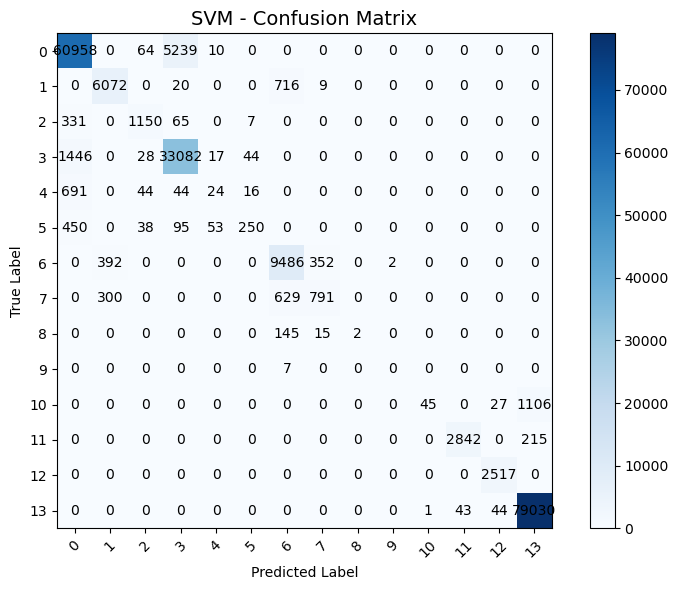


================ Decision Tree ================
F1 Score: 0.9627095155322285

Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98     66271
           1       0.92      0.88      0.90      6817
           2       1.00      0.54      0.71      1553
           3       0.98      0.99      0.99     34617
           4       0.00      0.00      0.00       819
           5       0.00      0.00      0.00       886
           7       0.93      0.93      0.93     10232
           8       0.55      0.69      0.61      1720
           9       0.00      0.00      0.00       162
          10       0.00      0.00      0.00         7
          11       0.58      0.22      0.32      1178
          12       0.99      0.93      0.96      3057
          13       1.00      1.00      1.00      2517
          14       0.99      1.00      0.99     79118

    accuracy                           0.97    208954
   macro avg       0.64      0.5

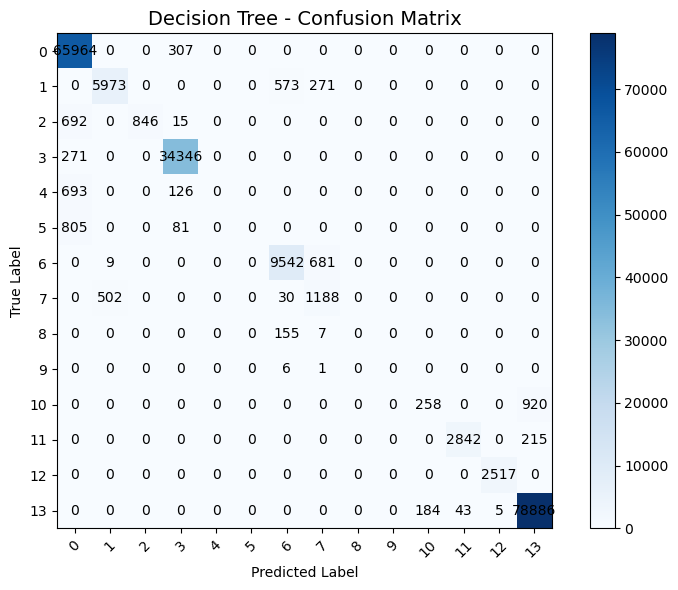


================ Random Forest ================
F1 Score: 0.9604567917809459

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98     66271
           1       0.93      0.90      0.91      6817
           2       1.00      0.51      0.67      1553
           3       0.98      0.99      0.99     34617
           4       1.00      0.49      0.66       819
           5       1.00      0.01      0.01       886
           7       0.84      1.00      0.91     10232
           8       0.99      0.11      0.20      1720
           9       0.00      0.00      0.00       162
          10       0.00      0.00      0.00         7
          11       1.00      0.01      0.01      1178
          12       0.99      0.93      0.96      3057
          13       0.99      1.00      1.00      2517
          14       0.98      1.00      0.99     79118

    accuracy                           0.97    208954
   macro avg       0.83      0.5

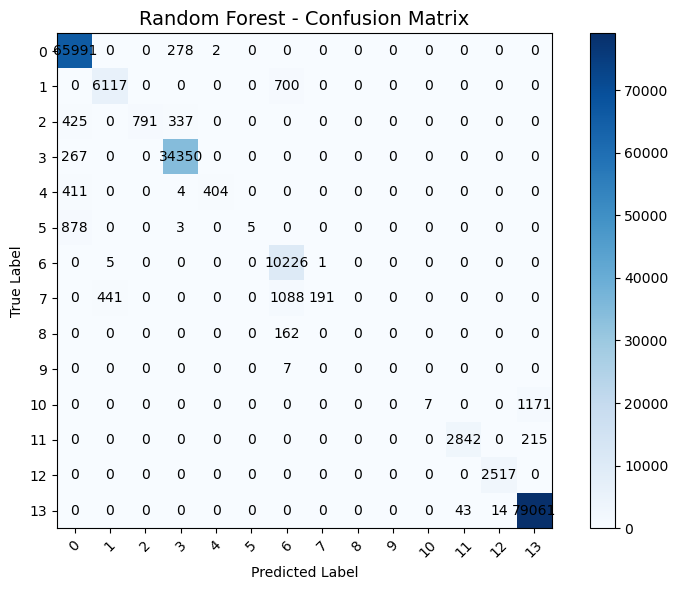


================ ANN ================
6530/6530 ━━━━━━━━━━━━━━━━━━━━ 18s 3ms/step
F1 Score: 0.9739185521739556

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.98      0.99     66271
           1       1.00      0.89      0.94      6817
           2       0.90      0.90      0.90      1553
           3       0.96      0.99      0.98     34617
           4       0.92      0.82      0.87       819
           5       0.94      0.75      0.83       886
           7       0.91      0.98      0.94     10232
           8       0.87      0.87      0.87      1720
           9       0.71      0.06      0.11       162
          10       0.00      0.00      0.00         7
          11       1.00      0.04      0.07      1178
          12       0.99      0.93      0.96      3057
          13       0.97      1.00      0.98      2517
          14       0.98      1.00      0.99     79118

    accuracy                           0.98    20895

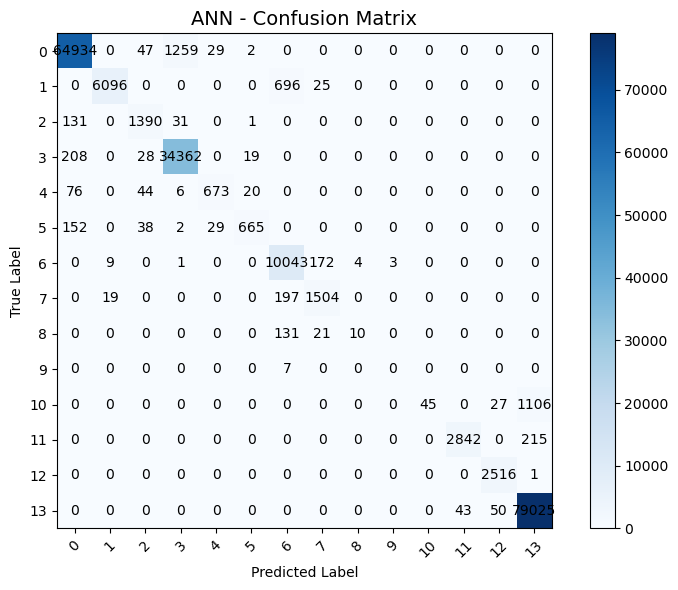


================ CNN ================
6530/6530 ━━━━━━━━━━━━━━━━━━━━ 21s 3ms/step
F1 Score: 0.9702026859837863

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.97      0.98     66271
           1       0.97      0.89      0.93      6817
           2       0.92      0.86      0.89      1553
           3       0.95      1.00      0.97     34617
           4       0.87      0.61      0.71       819
           5       0.82      0.75      0.78       886
           7       0.90      0.98      0.94     10232
           8       0.87      0.79      0.83      1720
           9       1.00      0.04      0.08       162
          10       0.00      0.00      0.00         7
          11       1.00      0.04      0.07      1178
          12       0.99      0.93      0.96      3057
          13       0.96      1.00      0.98      2517
          14       0.98      1.00      0.99     79118

    accuracy                           0.97    20895

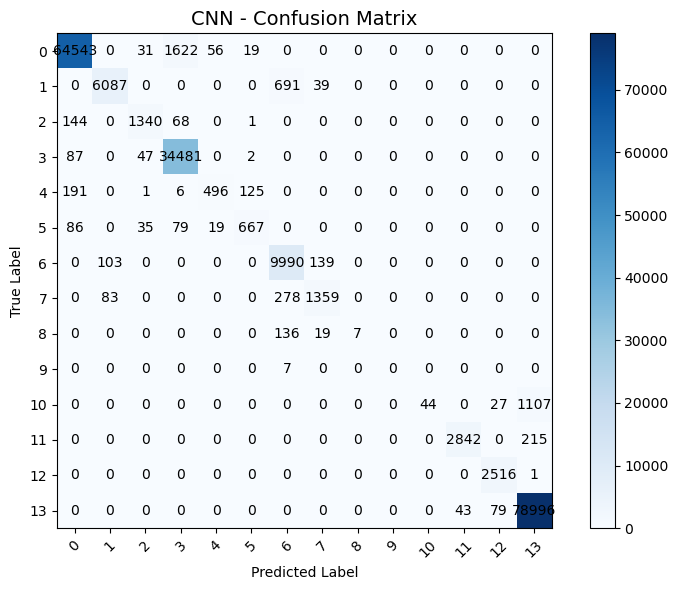


================ LSTM ================
6530/6530 ━━━━━━━━━━━━━━━━━━━━ 68s 10ms/step
F1 Score: 0.953872979946582

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.97      0.97     66271
           1       0.94      0.74      0.83      6817
           2       0.75      0.58      0.66      1553
           3       0.94      0.97      0.96     34617
           4       0.92      0.53      0.67       819
           5       0.75      0.48      0.58       886
           7       0.90      0.96      0.93     10232
           8       0.74      0.82      0.78      1720
           9       0.00      0.00      0.00       162
          10       0.00      0.00      0.00         7
          11       0.00      0.00      0.00      1178
          12       0.97      0.93      0.95      3057
          13       0.87      0.99      0.93      2517
          14       0.98      1.00      0.99     79118

    accuracy                           0.96    2089

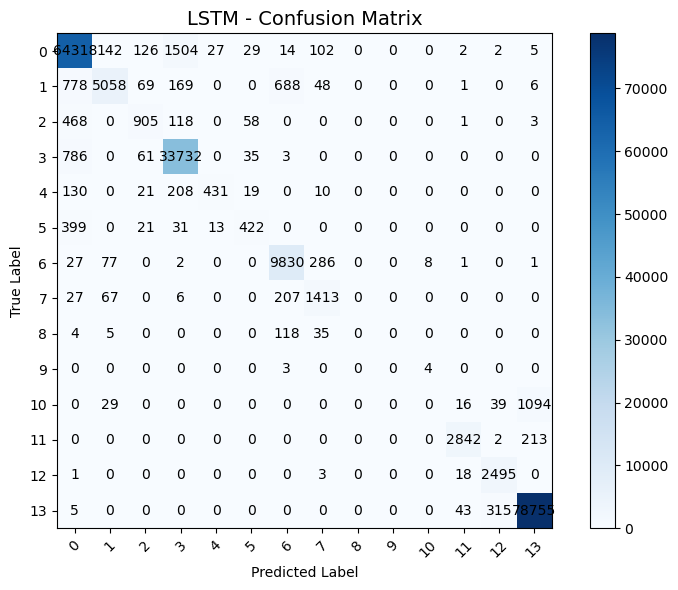

In [17]:
# ===========================
# CONFUSION MATRIX (COLOR FIXED + LARGE)
# ===========================

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, f1_score

for name, model in models.items():
    print(f"\n================ {name} ================")
    
    # ---------------------------
    # Predictions
    # ---------------------------
    y_pred_raw = model.predict(X_test)
    
    if len(y_pred_raw.shape) > 1:
        y_pred = np.argmax(y_pred_raw, axis=1)
    else:
        y_pred = y_pred_raw
    
    # ---------------------------
    # F1 Score
    # ---------------------------
    f1 = f1_score(y_test, y_pred, average='weighted')
    print("F1 Score:", f1)
    
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    
    # ---------------------------
    # CONFUSION MATRIX (CUSTOM PLOT)
    # ---------------------------
    cm = confusion_matrix(y_test, y_pred)
    
    fig, ax = plt.subplots(figsize=(8,6))  # Bigger size
    
    im = ax.imshow(cm, cmap='Blues')  # ✅ Color applied properly
    
    # Add color bar
    plt.colorbar(im)
    
    # Add numbers inside boxes
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j],
                    ha="center", va="center",
                    color="black", fontsize=10)
    
    # Labels
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")
    ax.set_title(f"{name} - Confusion Matrix", fontsize=14)
    
    # Ticks
    ax.set_xticks(np.arange(cm.shape[1]))
    ax.set_yticks(np.arange(cm.shape[0]))
    
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()